In [1]:
import numpy as np 
import pandas as pd 
import time 

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df = df[['Age','EstimatedSalary','Purchased']]

In [4]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [6]:
x.shape

(400, 2)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [8]:
x_scaled.shape

(400, 2)

In [9]:
from sklearn.model_selection import train_test_split 

x_train ,x_test, y_train, y_test = train_test_split(x_scaled,y , test_size=0.2 ,random_state=42)

In [10]:
x_train.shape

(320, 2)

In [11]:
import tensorflow as tf 
from tensorflow import keras 
from keras import Sequential 
from keras.layers import Dense ,Input

In [12]:
model = Sequential([
    Input(shape=(2,)),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()
hist = model.fit(x_scaled , y,epochs = 100 , batch_size = 1 ,validation_split = 0.2)
print(time.time() - start)

Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6969 - loss: 0.6194 - val_accuracy: 0.7750 - val_loss: 0.5954
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8125 - loss: 0.4379 - val_accuracy: 0.9125 - val_loss: 0.4831
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8625 - loss: 0.3296 - val_accuracy: 0.9250 - val_loss: 0.3772
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8687 - loss: 0.2906 - val_accuracy: 0.9125 - val_loss: 0.3184
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8719 - loss: 0.2841 - val_accuracy: 0.9125 - val_loss: 0.2832
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8719 - loss: 0.2781 - val_accuracy: 0.9125 - val_loss: 0.2585
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8719 - loss: 0.2769 - val_accuracy: 0.9375 - val_loss: 0.2416
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8813 - loss: 0.2721 - val_accu

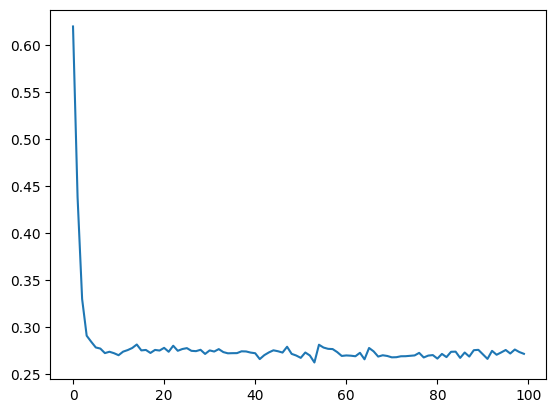

In [16]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])

In [17]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

D:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(x_scaled,y,epochs=10,batch_size=250,validation_split=0.2)
#print(time.time() - start)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 814ms/step - accuracy: 0.6375 - loss: 0.7202 - val_accuracy: 0.3625 - val_loss: 0.9745
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.6844 - loss: 0.7096 - val_accuracy: 0.3625 - val_loss: 0.9695
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.7000 - loss: 0.7032 - val_accuracy: 0.3625 - val_loss: 0.9673
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.7125 - loss: 0.6982 - val_accuracy: 0.3625 - val_loss: 0.9579
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.7125 - loss: 0.6941 - val_accuracy: 0.3625 - val_loss: 0.9578
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7125 - loss: 0.6904 - val_accuracy: 0.3625 - val_loss: 0.9519
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7125 - loss: 0.6872 - val_accuracy: 0.3625 - val_loss: 0.9508
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.7125 - loss: 0.6841 - val_accuracy: 0.3625 - val_loss:

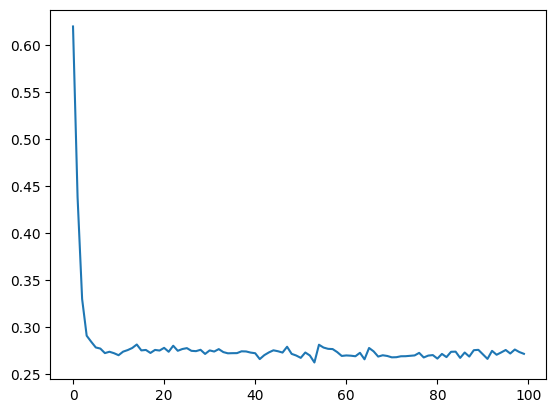

In [22]:
plt.plot(hist.history['loss'])